# Imports

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# 1. Создадим сигнал прямоугольных периодических импульсов и немного свернем его

## Создадим пространство и сигнал

In [2]:
N = 10000
a = -10
b =  10
X = np.linspace(a, b, N)

freq = 0.2

meandr = (np.sign(np.sin(2 * np.pi * freq * X)) + 1) / 2


## Свернем сигнал

$$y = Ae^{-x^2}$$

In [3]:
kernel_gauss = np.exp(-X**2)
kernel_gauss = kernel_gauss / np.sum(kernel_gauss) # Нормализация

In [4]:
conv_gauss = np.convolve(meandr, kernel_gauss, 'same')

## Свернем сигнал

$$y = 2x+1$$

In [5]:
lin_ker_list = [-x+1 for x in range(np.int32(np.ceil(N / (b - a))))]
X_lin_kern = np.linspace(a, a + 5, np.int32(np.ceil(N / (b - a))))
kernel_lin = np.array(lin_ker_list)
kernel_lin = kernel_lin / np.sum(kernel_lin) # Нормализация

# Это работает, но лучше бы сделать это параметрическим, а не + 5...


In [6]:
conv_lin = np.convolve(meandr, kernel_lin, 'same')

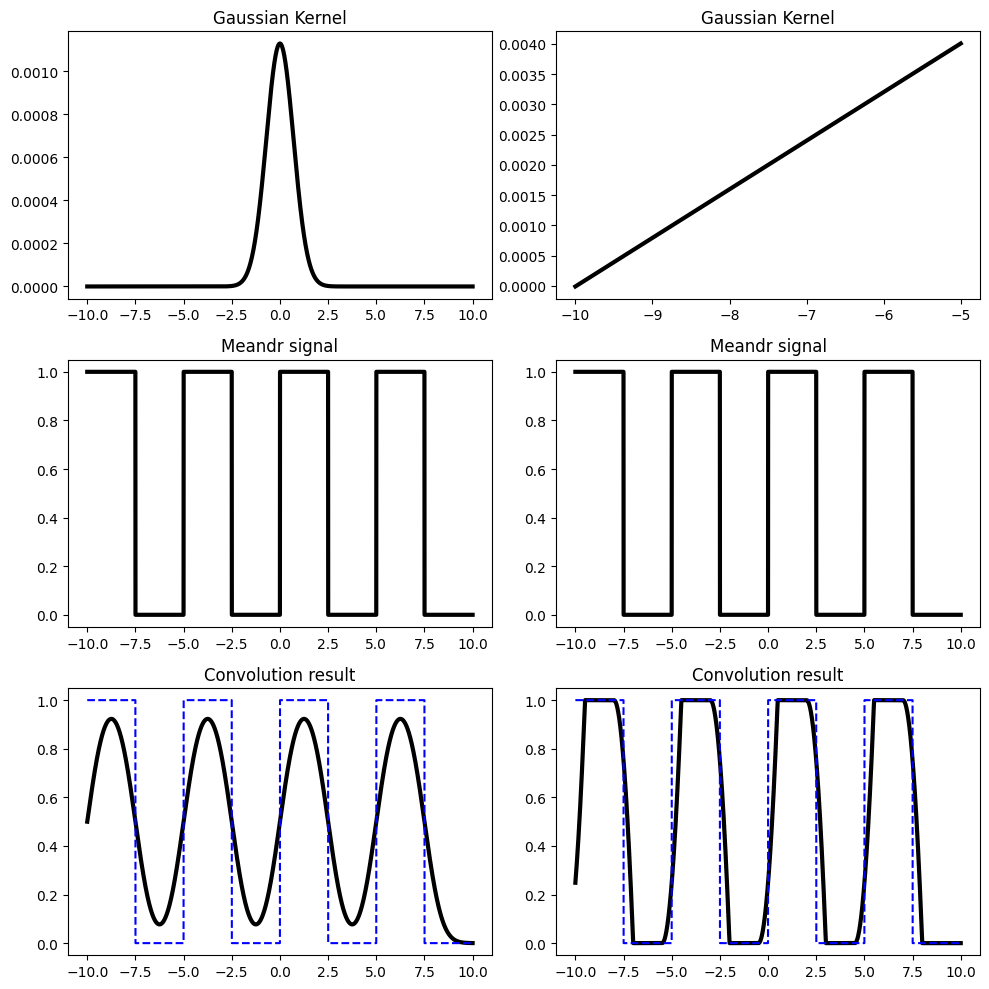

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(10,10))

# Гауссово ядро
axes[0][0].plot(X, kernel_gauss, color='black', linewidth=3)
axes[0][0].set_title("Gaussian Kernel")

axes[1][0].plot(X, meandr, color='black', linewidth=3)
axes[1][0].set_title("Meandr signal")

axes[2][0].plot(X, conv_gauss, color='black', linestyle='-', linewidth=3)
axes[2][0].plot(X, meandr, color='blue', linestyle='--')
axes[2][0].set_title("Convolution result")

# Линейное ядро
axes[0][1].plot(X_lin_kern, kernel_lin, color='black', linewidth=3)
axes[0][1].set_title("Gaussian Kernel")

axes[1][1].plot(X, meandr, color='black', linewidth=3)
axes[1][1].set_title("Meandr signal")

axes[2][1].plot(X, conv_lin, color='black', linestyle='-', linewidth=3)
axes[2][1].plot(X, meandr, color='blue', linestyle='--')
axes[2][1].set_title("Convolution result")

plt.tight_layout()

# 2. Реализуем алгоритм свертки двух сигналов с произвольным ядром

In [8]:
def convolution_my(func, kernel, type='same'):
    result = [0 for _ in func]
    
    for k in range(len(func)):
        for n in range(len(kernel)):
            result[n] += func[k] * kernel[n - k]

    return result


Код ниже и выше очень долго выполняется т.к. имеет сложность O(N*M)

С маленькими ядрами ок, но дальше жесть

In [9]:
import numpy as np

def convolution_slow(func, kernel, mode='same'):
    func = np.array(func)
    kernel = np.array(kernel)
    
    # Полная свёртка (full)
    full_len = len(func) + len(kernel) - 1
    result_full = np.zeros(full_len)
    
    for i in range(full_len):
        for j in range(len(kernel)):
            k = i - j
            if 0 <= k < len(func):
                result_full[i] += func[k] * kernel[j]
    
    if mode == 'same':
        # Центральная часть той же длины, что и func
        pad = len(kernel) // 2
        result = result_full[pad:pad + len(func)]
    elif mode == 'full':
        result = result_full
    else:
        raise ValueError("mode must be 'same' or 'full'")
    
    return result

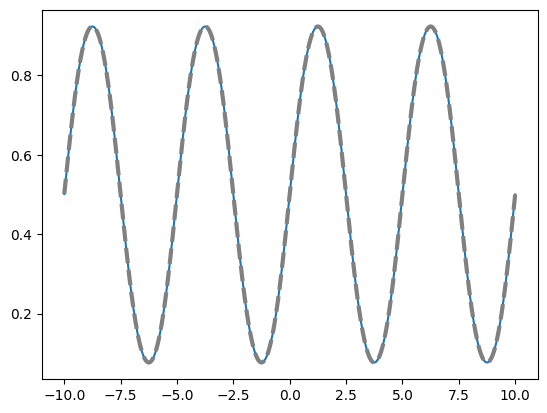

In [68]:
# conv_gauss = convolution_slow(meandr, kernel_gauss, 'same')

plt.plot(X, conv_gauss)
plt.plot(X, conv_gauss, color='grey', linestyle='--', linewidth=3)

Напишем свертку быстрее - O(Nlog(N))
Пользуясь теоремой о свертке


In [11]:
def convolution(func, kernel, mode='same'):
    return np.fft.ifft(np.fft.fft(func)*np.fft.fft(kernel))

/Users/nov/Documents/NSU2026/DSP/Task4/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nov/Documents/NSU2026/DSP/Task4/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


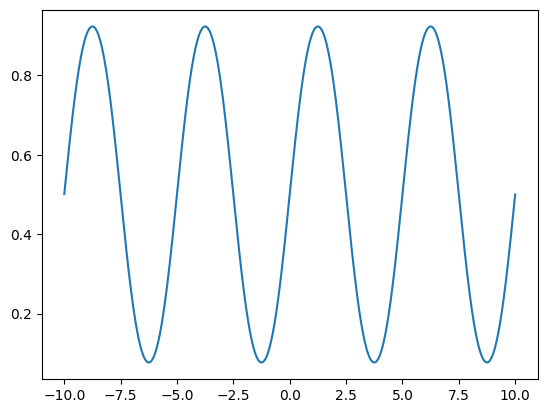

In [12]:
conv_gauss = convolution(meandr, kernel_gauss, 'same')

plt.plot(X, conv_gauss)

# 3. Убедимся на примере Гауссова ядра в отм, что свертка во временной области эквивалентна умножению в частотной

In [13]:
# Preparations

dt = X[1] - X[0]

fft_meandr = np.fft.fft(meandr)

fft_gauss = np.fft.fft(kernel_gauss)

fft_conv_gauss = np.fft.fft(conv_gauss)

freq = np.fft.fftfreq(N, dt)

multiplication_fft_meandr_gauss = fft_meandr * fft_gauss

ifft_multiplication_fft_meandr_gauss = np.fft.ifft(multiplication_fft_meandr_gauss) # Time space


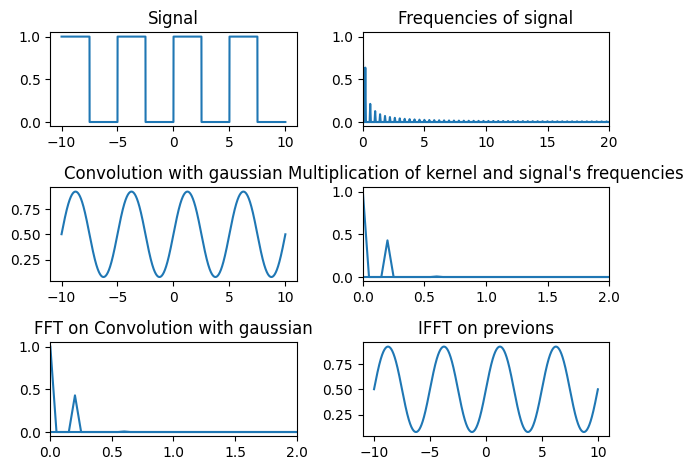

In [14]:
fig, axes = plt.subplots(3, 2)

# Для свертки в пространстве времени
axes[0][0].plot(X, meandr)
axes[0][0].set_title("Signal")

axes[1][0].plot(X, conv_gauss)
axes[1][0].set_title("Convolution with gaussian")

axes[2][0].plot(freq, np.abs(fft_conv_gauss)/N*2)
axes[2][0].set_title("FFT on Convolution with gaussian")
axes[2][0].set_xlim(0, 2)

# Для умножения в пространстве частот
axes[0][1].plot(freq, np.abs(fft_meandr)/N*2)
axes[0][1].set_title("Frequencies of signal")
axes[0][1].set_xlim(0, 20)

axes[1][1].plot(freq, np.abs(multiplication_fft_meandr_gauss)/N*2)
axes[1][1].set_title("Multiplication of kernel and signal's frequencies")
axes[1][1].set_xlim(0, 2)

axes[2][1].plot(X, ifft_multiplication_fft_meandr_gauss)
axes[2][1].set_title("IFFT on previons")

plt.tight_layout()

# 4. Разберемся со сглаживающим фильтром Гаусса

Просто гауссиан, который я сразу вспомнил
$$\alpha e^{-(\frac{(x-\mu)}{\sqrt{2}\sigma})^2}$$

То, с чем буду работать - непосредственно сам объект исследования:

$$\Large g = e^{-\frac{1}{2}\left(\frac{h-p}{s}\right)^2}$$

Далее разберемся с тем, что нам ещё предложили

$$s = \frac{w(2\pi - 1)}{4\pi}$$

**h: frequencies**

**p: peak frequency**

**w: Full Width of Half Maximum**

w подбирается эмпирически. Это лишь удобный параметр для того, чтобы задать Гауссиан и делать его шире или уже

p - частота на которую будет настроен фильтр


# 5. Попробуем применить этот фильтр как ФНЧ и ПФ для сигнала из прошлой лабораторной

In [15]:
def cos_50(x):
    return np.cos(2 * np.pi * 50 * x)

def cos_150(x):
    return np.cos(2 * np.pi * 150 * x)

def cos_450(x):
    return np.cos(2 * np.pi * 450 * x)

In [16]:
N_h = 20000

h = np.linspace(-1/10, 1/10, N_h)
func = cos_50(h) + cos_150(h) + cos_450(h)

dt_h = h[1] - h[0]
freq_h = np.fft.fftfreq(N_h, dt_h)

##  Создадим фильтр низких частот.

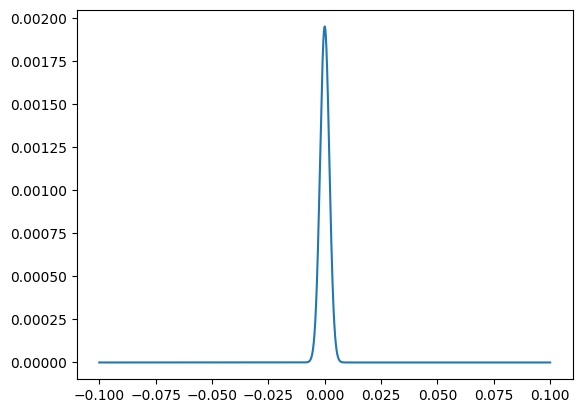

In [17]:
w = 0.006
s = w*(2*(np.pi-1))/(4*np.pi)
p = 0

gauss_filter_lf = np.exp(-1/2*((h-p)/s)**2)
gauss_filter_lf = gauss_filter_lf/np.sum(gauss_filter_lf)


plt.plot(h, gauss_filter_lf)

In [18]:


func_fft = np.fft.fft(func)
gauss_filter_lf_fft = np.fft.fft(gauss_filter_lf)

conv_gauss_lf_cos = np.convolve(func, gauss_filter_lf, 'same')
conv_gauss_lf_cos_fft = np.fft.fft(conv_gauss_lf_cos)

In [19]:
freq_bound_l = 0
freq_bound_h = 500


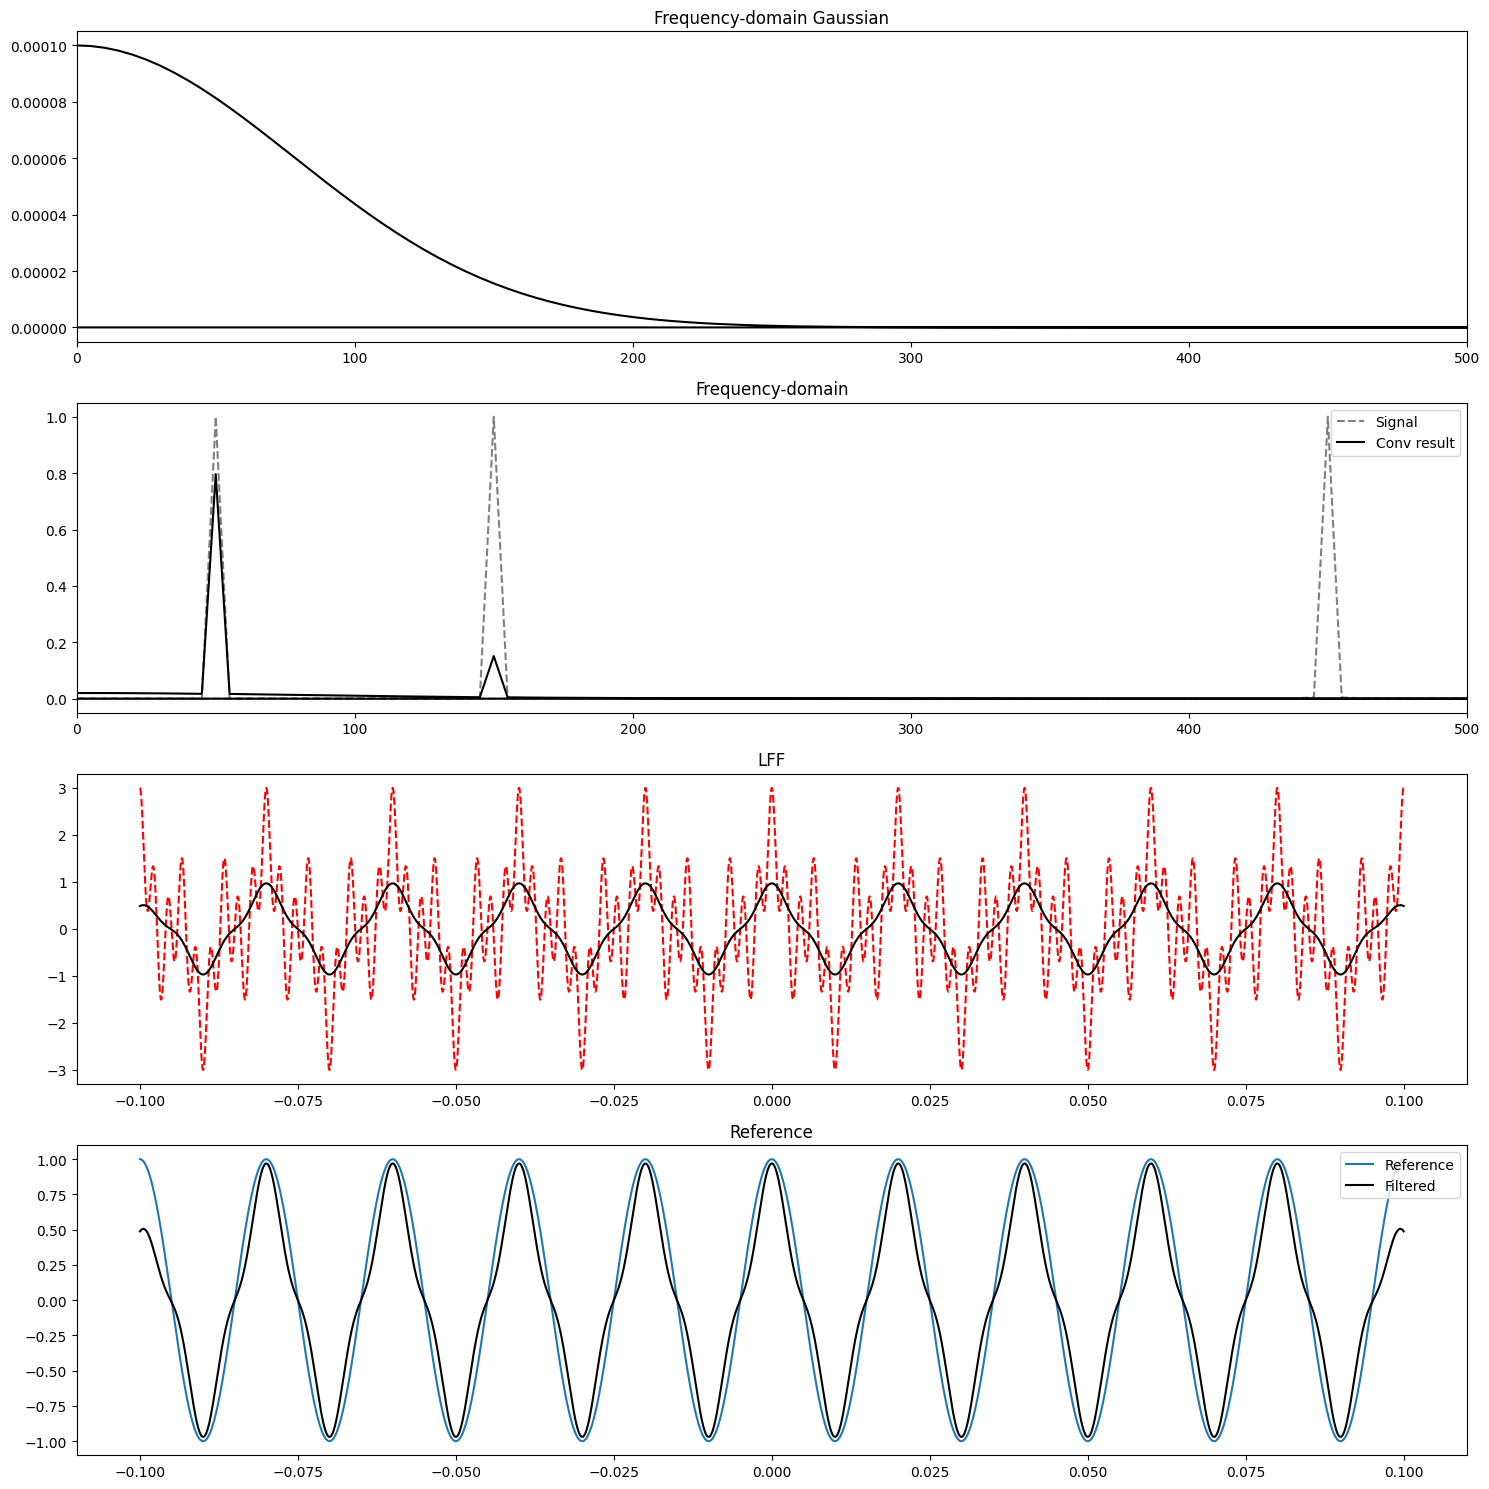

In [20]:


fig, axes = plt.subplots(4, 1, figsize=(15,15))

# Для Фильтра в пространстве частот
axes[0].plot(freq_h, np.abs(gauss_filter_lf_fft)/N_h*2, color='black')
axes[0].set_title("Frequency-domain Gaussian")
axes[0].set_xlim(freq_bound_l, freq_bound_h)

axes[1].plot(freq_h, np.abs(func_fft)/N_h*2, color='grey', linestyle='--', label="Signal")
axes[1].plot(freq_h, np.abs(conv_gauss_lf_cos_fft)/N_h*2, color='black', label="Conv result")
axes[1].set_title("Frequency-domain")
axes[1].legend()
axes[1].set_xlim(freq_bound_l, freq_bound_h)


axes[2].plot(h, func, color="red", linestyle='--', label="Signal")
axes[2].plot(h, conv_gauss_lf_cos, color="black", label="Filtered")
axes[2].set_title("LFF")

axes[3].plot(h, cos_50(h), label='Reference')
axes[3].plot(h, conv_gauss_lf_cos, color="black", label="Filtered")
axes[3].set_title("Reference")
axes[3].legend()


plt.tight_layout()

##  Создадим узкополосный фильтр.

(-200.0, 200.0)

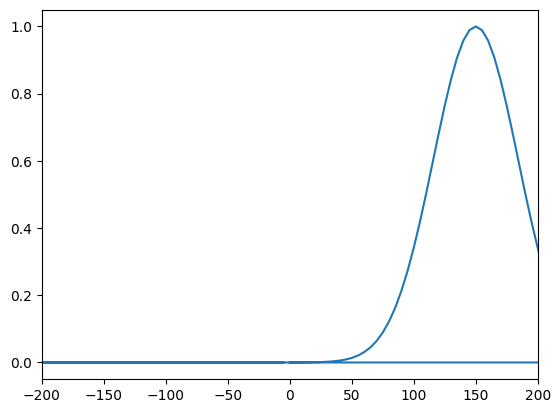

In [21]:
w = 100
s = w*(2*(np.pi-1))/(4*np.pi)
p = 150

gauss_filter_nb = np.exp(-1/2*((freq_h-p)/s)**2)
# gauss_filter_nb = gauss_filter_nb/np.sum(gauss_filter_nb)


plt.plot(freq_h, gauss_filter_nb)
plt.xlim(-200, 200)

In [22]:

mult_gauss_nb_cos = func_fft * gauss_filter_nb
mult_gauss_nb_cos_ifft = np.fft.ifft(mult_gauss_nb_cos) * 2

(-200.0, 200.0)

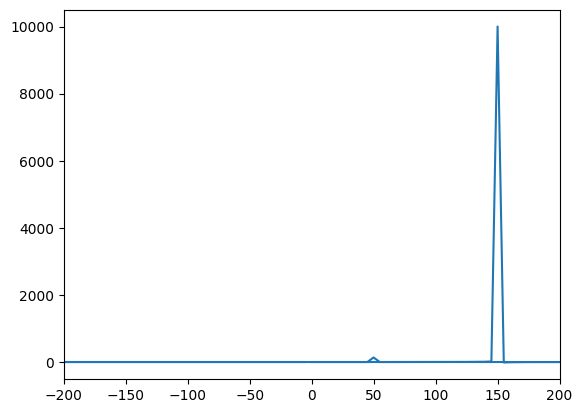

In [23]:
plt.plot(freq_h, mult_gauss_nb_cos)
plt.xlim(-200, 200)

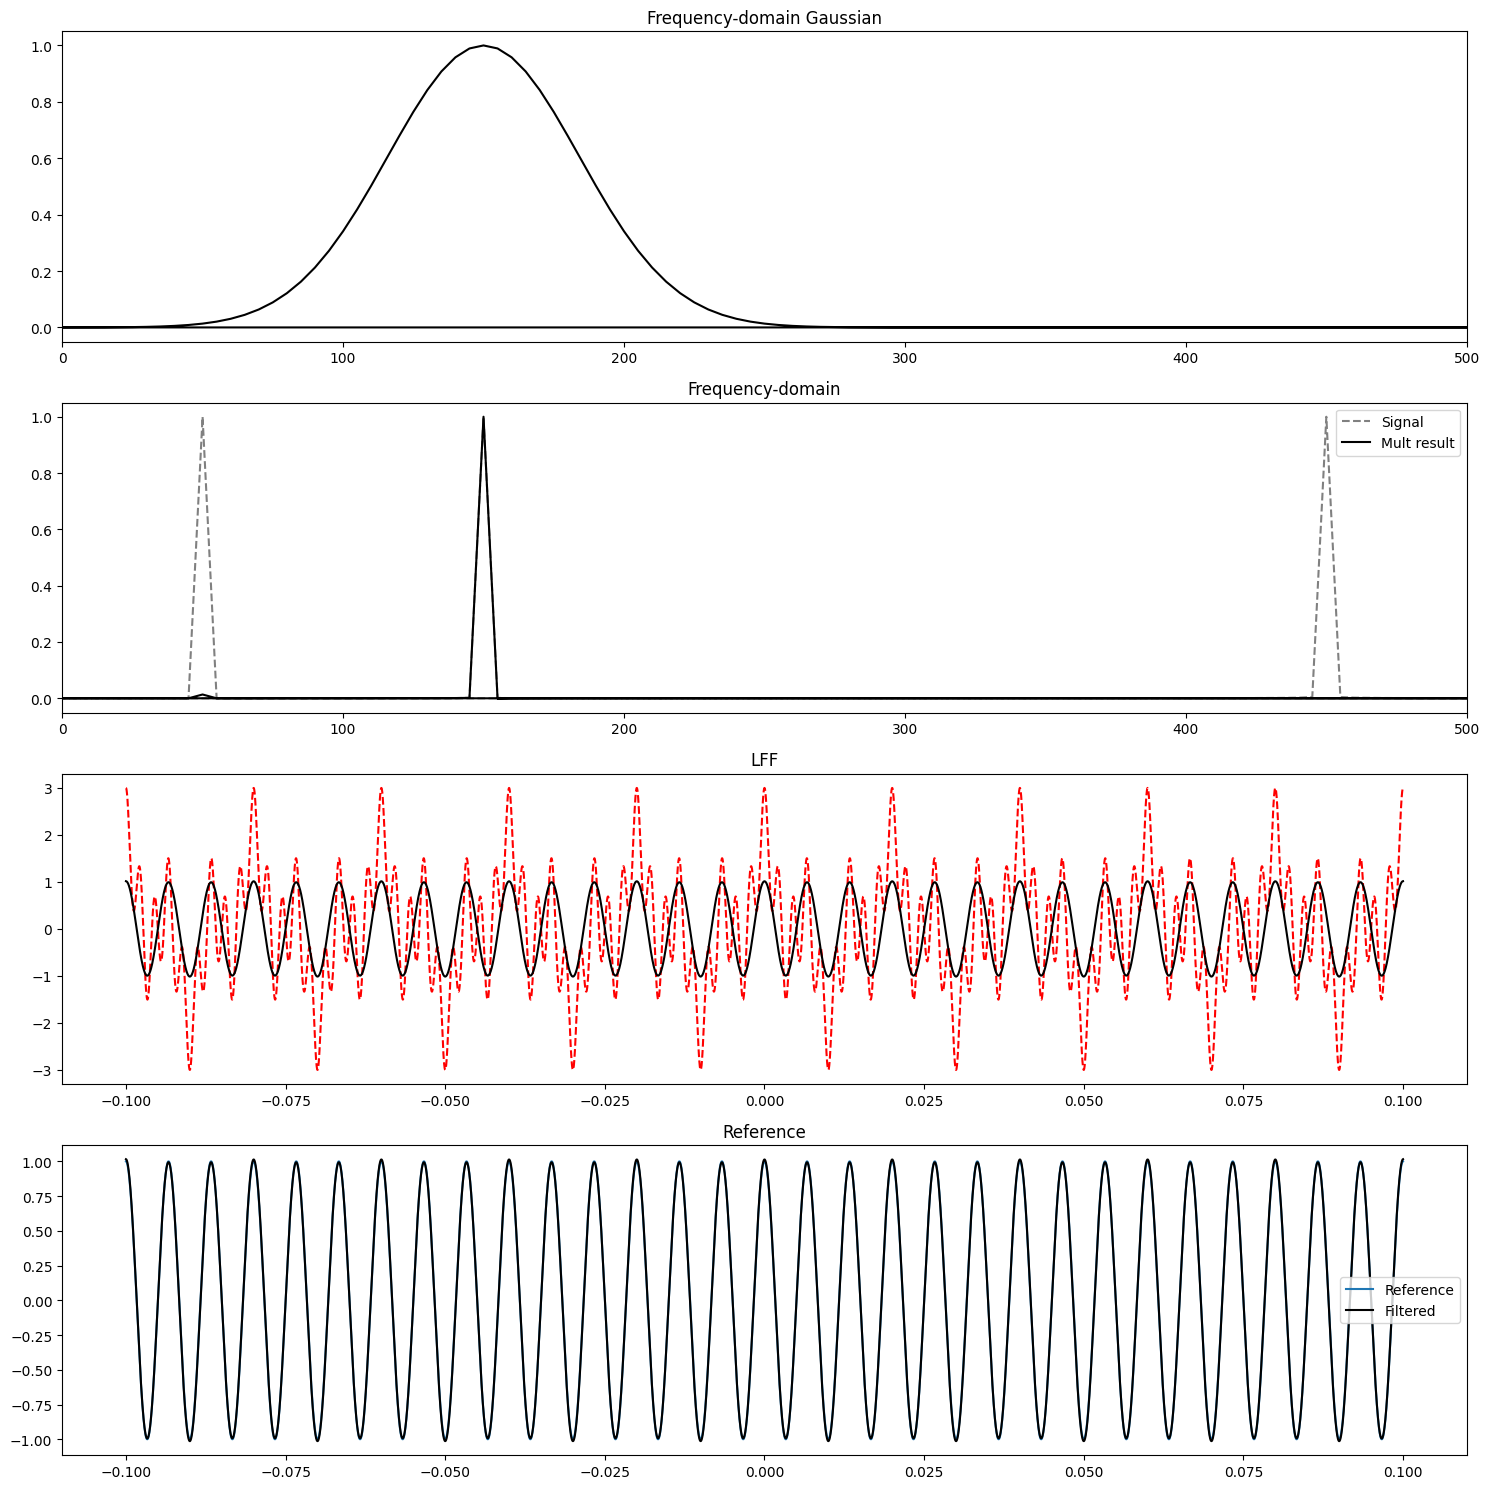

In [70]:
fig, axes = plt.subplots(4, 1, figsize=(15,15))

# Для Фильтра в пространстве частот
axes[0].plot(freq_h, gauss_filter_nb, color='black')
axes[0].set_title("Frequency-domain Gaussian")
axes[0].set_xlim(freq_bound_l, freq_bound_h)

axes[1].plot(freq_h, np.abs(func_fft)/N_h*2, color='grey', linestyle='--', label="Signal")
axes[1].plot(freq_h, mult_gauss_nb_cos/N_h*2, color='black', label="Mult result")
axes[1].set_title("Frequency-domain")
axes[1].legend()
axes[1].set_xlim(freq_bound_l, freq_bound_h)


axes[2].plot(h, func, color="red", linestyle='--', label="Signal")
axes[2].plot(h, mult_gauss_nb_cos_ifft, color="black", label="Filtered")
axes[2].set_title("LFF")

axes[3].plot(h, cos_150(h), label='Reference')
axes[3].plot(h, mult_gauss_nb_cos_ifft, color="black", label="Filtered")
axes[3].set_title("Reference")
axes[3].legend()


plt.tight_layout()

# 6. Реализовать полосоворй фильтр, используя окно Планка

$$
\left\{
\begin{aligned}
&\dfrac{1}{e^{z_l(t)} + 1} , && 0 < t < N - 1 \\
&1 , && \epsilon(N-1) \leq t \leq N-1 \\
&\dfrac{1}{e^{z_r(t)} + 1} , && (1 - \epsilon)(N - 1) < t < N - 1
\end{aligned}
\right.
$$

$$z_l(t)=\epsilon(N - 1)(\frac{1}{t} + \frac{1}{t-\epsilon(N-1)})$$
$$z_r(t)=\epsilon(N - 1)(\frac{1}{N-1-t} + \frac{1}{(1-\epsilon)(N-1)-t})$$

$$0 < \epsilon \le \frac{1}{2}$$


/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_9177/2904595914.py:17: RuntimeWarning: overflow encountered in exp
  plank_window[1:int(eps*(N_tm1))] = 1 / (np.exp(z_l) + 1)
/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_9177/2904595914.py:22: RuntimeWarning: overflow encountered in exp
  plank_window[N_tm1-int(eps*(N_tm1)):N_tm1] = 1 / (np.exp(z_r) + 1)


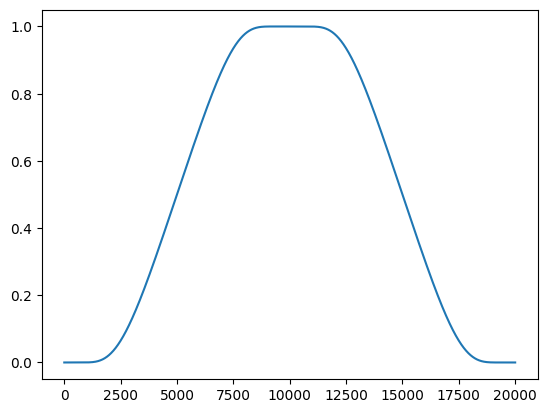

In [44]:
N_t = 20000
N_tm1 = N_t - 1

n = np.arange(N_t)
plank_window = np.ones(N_t)

t = np.linspace(-1/10, 1/10, N_t)
func = cos_50(t) + cos_150(t) + cos_450(t)

dt_t = t[1] - t[0]
freq_t = np.fft.fftfreq(N_t, dt_t)

eps = 0.5

n_left = n[1:int(eps*(N_tm1))]
z_l = int(eps * (N_tm1)) * (1/n_left + 1/(n_left - int(eps*(N_tm1))))
plank_window[1:int(eps*(N_tm1))] = 1 / (np.exp(z_l) + 1)


n_right = n[N_tm1 - int(eps*(N_tm1)):N_tm1]
z_r = eps * (N_tm1) * (1/(N_tm1 - n_right) + 1/((1 - eps) * (N_tm1) - n_right))
plank_window[N_tm1-int(eps*(N_tm1)):N_tm1] = 1 / (np.exp(z_r) + 1)

plank_window[0] = 0
plank_window[-1] = 0

plt.plot(plank_window)

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_9177/942431877.py:76: RuntimeWarning: overflow encountered in exp
  plank_window[mask_right] = 1 / (np.exp(-z_right) + 1)


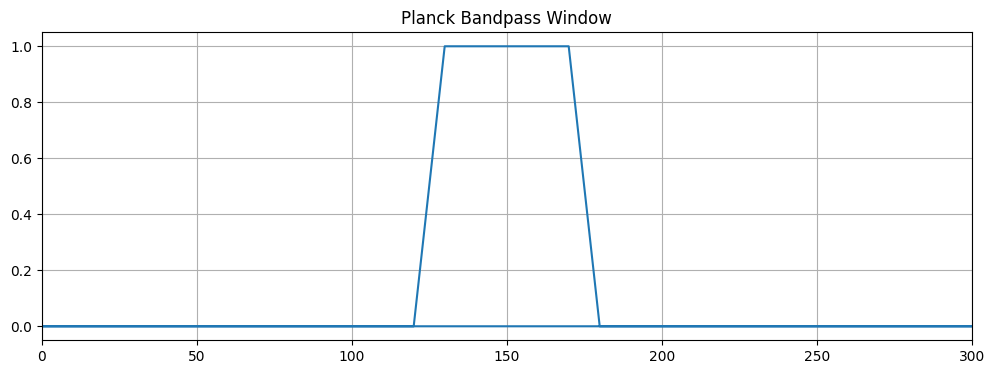

In [47]:

# ======================
# SIGNAL
# ======================

N_t = 20000

t = np.linspace(-0.1, 0.1, N_t)

def cos_50(t):
    return np.cos(2*np.pi*50*t)

def cos_150(t):
    return np.cos(2*np.pi*150*t)

def cos_450(t):
    return np.cos(2*np.pi*450*t)

func = cos_50(t) + cos_150(t) + cos_450(t)

# ======================
# FFT GRID
# ======================

dt_t = t[1] - t[0]

freq_t = np.fft.fftfreq(N_t, dt_t)

# ======================
# PLANCK BANDPASS WINDOW
# ======================

plank_window = np.zeros(N_t)

f0 = 150        # center frequency
band = 20       # passband half-width
eps = 10        # transition width in Hz

abs_f = np.abs(freq_t)

# regions
f1 = f0 - band - eps
f2 = f0 - band
f3 = f0 + band
f4 = f0 + band + eps

# ----------------------
# LEFT TRANSITION
# ----------------------

mask_left = (abs_f > f1) & (abs_f < f2)

x_left = (abs_f[mask_left] - f1) / (f2 - f1)

z_left = 1/x_left + 1/(x_left - 1)

plank_window[mask_left] = 1 / (np.exp(z_left) + 1)

# ----------------------
# PASSBAND
# ----------------------

mask_mid = (abs_f >= f2) & (abs_f <= f3)

plank_window[mask_mid] = 1

# ----------------------
# RIGHT TRANSITION
# ----------------------

mask_right = (abs_f > f3) & (abs_f < f4)

x_right = (abs_f[mask_right] - f3) / (f4 - f3)

z_right = 1/x_right + 1/(x_right - 1)

plank_window[mask_right] = 1 / (np.exp(-z_right) + 1)

# ======================
# APPLY FILTER
# ======================

F = np.fft.fft(func)

F_filtered = F * plank_window

filtered = np.real(np.fft.ifft(F_filtered))

# ======================
# PLOTS
# ======================

plt.figure(figsize=(12,4))
plt.plot(freq_t, plank_window)
plt.xlim(0, 300)
plt.grid()
plt.title("Planck Bandpass Window")
plt.show()

In [63]:
mult_plank_cos = plank_window * func_fft
mult_plank_cos_ifft = np.fft.ifft(mult_plank_cos)


# 7. Сравним результаты фильтрации сверткой с гауссовым фильтром и окном планка

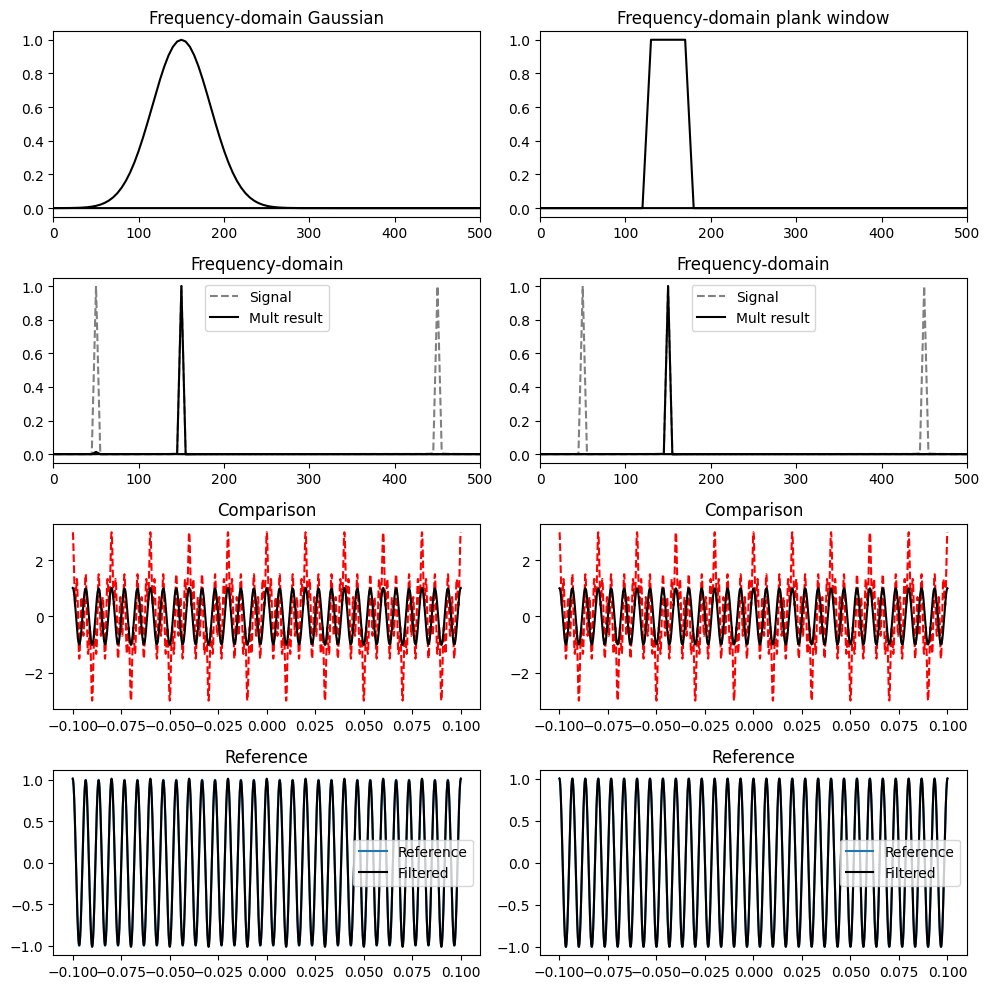

In [71]:
fig, axes = plt.subplots(4, 2, figsize=(10,10))

# Для Фильтра в пространстве частот
axes[0][0].plot(freq_h, gauss_filter_nb, color='black')
axes[0][0].set_title("Frequency-domain Gaussian")
axes[0][0].set_xlim(freq_bound_l, freq_bound_h)

axes[0][1].plot(freq_h, plank_window, color='black')
axes[0][1].set_title("Frequency-domain plank window")
axes[0][1].set_xlim(freq_bound_l, freq_bound_h)

axes[1][0].plot(freq_h, np.abs(func_fft)/N_h*2, color='grey', linestyle='--', label="Signal")
axes[1][0].plot(freq_h, mult_gauss_nb_cos/N_h*2, color='black', label="Mult result")
axes[1][0].set_title("Frequency-domain")
axes[1][0].legend()
axes[1][0].set_xlim(freq_bound_l, freq_bound_h)

axes[1][1].plot(freq_h, np.abs(func_fft)/N_h*2, color='grey', linestyle='--', label="Signal")
axes[1][1].plot(freq_h, mult_plank_cos/N_h*2, color='black', label="Mult result")
axes[1][1].set_title("Frequency-domain")
axes[1][1].legend()
axes[1][1].set_xlim(freq_bound_l, freq_bound_h)

axes[2][0].plot(h, func, color="red", linestyle='--', label="Signal")
axes[2][0].plot(h, mult_gauss_nb_cos_ifft, color="black", label="Filtered")
axes[2][0].set_title("Comparison")

axes[2][1].plot(h, func, color="red", linestyle='--', label="Signal")
axes[2][1].plot(h, mult_plank_cos_ifft, color="black", label="Filtered")
axes[2][1].set_title("Comparison")

axes[3][0].plot(h, cos_150(h), label='Reference')
axes[3][0].plot(h, mult_gauss_nb_cos_ifft, color="black", label="Filtered")
axes[3][0].set_title("Reference")
axes[3][0].legend()

axes[3][1].plot(h, cos_150(h), label='Reference')
axes[3][1].plot(h, mult_plank_cos_ifft, color="black", label="Filtered")
axes[3][1].set_title("Reference")
axes[3][1].legend()

plt.tight_layout()